In [7]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [8]:
# Step 2: Create a simple dataset
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # sine wave with noise

In [9]:
# Step 3: Fit Gradient Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=5,      # number of weak learners
    learning_rate=0.5,   # step size
    max_depth=2,         # depth of each tree
    random_state=42
)
gbr.fit(X, y)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.5
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",5
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft ch

In [10]:
# Step 4: Make predictions
y_pred = gbr.predict(X)

In [11]:
# Step 5: Compute error
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.048856982008667026


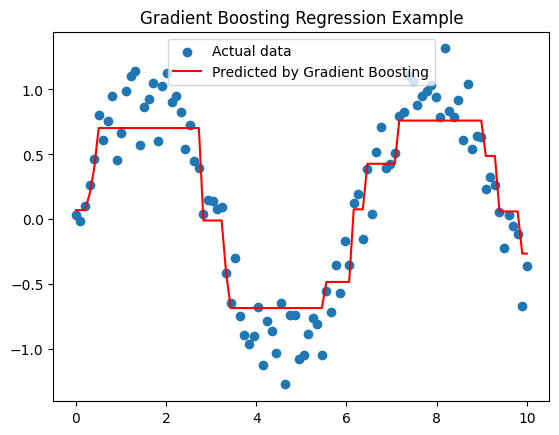

In [12]:
# Step 6: Visualize predictions
plt.scatter(X, y, label="Actual data")
plt.plot(X, y_pred, color='red', label="Predicted by Gradient Boosting")
plt.title("Gradient Boosting Regression Example")
plt.legend()
plt.show()

In [13]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Simple data
X = np.array([[1],[2],[3],[4],[5]])
y = np.array([1.5, 1.7, 3.2, 3.8, 5.1])

# Step 0: initial prediction
F = np.mean(y) * np.ones(len(y))
print("Initial prediction:", F)

for m in range(3):  # 3 boosting rounds
    # Step 1: residuals
    residuals = y - F
    print(f"\nStep {m+1} residuals:", residuals)

    # Step 2: fit tree on residuals
    tree = DecisionTreeRegressor(max_depth=1)
    tree.fit(X, residuals)

    # Step 3: update prediction
    learning_rate = 0.5
    F += learning_rate * tree.predict(X)

    print("Updated predictions:", F)

Initial prediction: [3.06 3.06 3.06 3.06 3.06]

Step 1 residuals: [-1.56 -1.36  0.14  0.74  2.04]
Updated predictions: [2.33       2.33       3.54666667 3.54666667 3.54666667]

Step 2 residuals: [-0.83       -0.63       -0.34666667  0.25333333  1.55333333]
Updated predictions: [2.13583333 2.13583333 3.3525     3.3525     4.32333333]

Step 3 residuals: [-0.63583333 -0.43583333 -0.1525      0.4475      0.77666667]
Updated predictions: [1.93180556 1.93180556 3.14847222 3.65854167 4.629375  ]
